# Futures Backtest Viewer

Runs (or loads a saved run of) one UID (same grammar as
`runners/run_futures_strats.py`) and gives you:

1. The tradebook for that run.
2. A TradingView-style chart -- candlesticks, the price-overlay indicators the
   strategy actually used (from `dcemachop`: Donchian bands + EMA), trade
   markers, and the two filter indicators (ADX, Choppiness) as sub-panels
   with their threshold lines.

The chart is built from `signals` (`BaseFuturesStrategy`'s per-bar signal
log), not from a separate indicator recomputation -- that log already
carries the exact `donchian_upper`/`donchian_lower`/`ema`/`adx`/`chop`
values the strategy saw at each decision point, so the chart is guaranteed
to match what actually drove the trades.

This is written for `dcemachop`. To adapt it for `stema` or `psarema`,
swap the overlay/panel section near the bottom for their signal log
columns instead (`supertrend`/`ema` for stema, `psar`/`ema` for psarema).

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import mplfinance as mpf
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from strategies.futures.factory import create_futures_strategy
from data.resample import timeframe_to_timedelta

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

print("Setup OK")

Setup OK


## Configure the run

Same shape as `runners/run_futures_strats.py` -- edit these to view a
different UID, symbol, date range, or data source. See
`strategies/futures/README.md` for the UID grammar and what's available
under each `duckdb/*.duckdb` file.

`PLOT_START_DATE`/`PLOT_END_DATE` are separate from the backtest's own
`START_DATE`/`END_DATE` -- the backtest still runs (or loads) the full
window, this just narrows what the chart draws. Use the tradebook cell to
find a date worth a closer look, then narrow these down to zoom in on it.

In [49]:
UID = "dcemachop__s=MES__dc=20__ema=200__adx_period=14__adx=25__chop_period=14__chop=35__atr=14__sl_atr=2"
CAPITAL = 50_000.0

DB_PATH = PROJECT_ROOT / "duckdb" / "futures_data_1h.duckdb"
SOURCE_TIMEFRAME = "1h"
TIMEFRAME = "1h"

START_DATE = None  # backtest start (None = full history)
END_DATE = None            # backtest end

# True = skip re-running and load a previous run's saved results from
# results/futures/<strategy>/<uid>/ instead (written by
# runners/run_futures_strats.py, or by this notebook's own run below).
LOAD_SAVED_RESULTS = False



## Run (or load) the backtest

In [50]:
strategy = create_futures_strategy(
    uid=UID,
    capital=CAPITAL,
    db_path=DB_PATH,
    timeframe=TIMEFRAME,
    source_timeframe=SOURCE_TIMEFRAME,
)

strategy_name = UID.split("__", 1)[0].strip().lower()
run_dir = PROJECT_ROOT / "results" / "futures" / strategy_name / UID

if LOAD_SAVED_RESULTS:
    if not run_dir.exists():
        raise FileNotFoundError(
            f"No saved results at {run_dir}\n"
            "Run runners/run_futures_strats.py with this UID first, or set "
            "LOAD_SAVED_RESULTS = False to run it here instead."
        )
    tradebook = pd.read_csv(run_dir / "tradebook.csv")
    signals = pd.read_csv(run_dir / "signal_log.csv")
    equity = pd.read_csv(run_dir / "equity.csv")
    print(f"Loaded saved results from: {run_dir}")
else:
    result = strategy.run(start=START_DATE, end=END_DATE)
    tradebook = result["tradebook"]
    signals = result["signals"]
    equity = result["equity"]
    print("Ran a fresh backtest (set LOAD_SAVED_RESULTS = True to skip this next time).")

print(f"UID:          {UID}")
print(f"Data symbol:  {strategy.data_symbol}")
print(f"Trades:       {len(tradebook)}")
print(f"Bars seen:    {len(signals)}")
if not equity.empty:
    print(f"Final equity: ${equity['equity'].iloc[-1]:,.2f}")

Ran a fresh backtest (set LOAD_SAVED_RESULTS = True to skip this next time).
UID:          dcemachop__s=MES__dc=20__ema=200__adx_period=14__adx=25__chop_period=14__chop=35__atr=14__sl_atr=2
Data symbol:  MES=F
Trades:       382
Bars seen:    30343
Final equity: $49,852.60


## Tradebook

Every entry, exit, and stop-out, in order. `reason` tells you why the
trade happened (`SIGNAL_ENTRY`, `SIGNAL_EXIT`, `SIGNAL_REVERSAL_*`, or
`ATR_STOP`) -- use this to find dates worth zooming in on below.

In [51]:
tradebook_view = tradebook[[
    "timestamp", "action", "price", "contracts", "reason",
    "entry_price", "stop_price", "realized_trade_pnl", "equity",
]].copy()
tradebook_view["timestamp"] = pd.to_datetime(tradebook_view["timestamp"])
tradebook_view

,timestamp,action,price,contracts,reason,entry_price,stop_price,realized_trade_pnl,equity
0,2021-01-19 00:00:00,BUY,3780.500000,1,SIGNAL_ENTRY,3780.50,3765.232719,0.000000,50000.000000
1,2021-01-27 14:00:00,SELL,3765.232719,1,ATR_STOP,3780.50,3765.232719,-76.336407,49923.663593
2,2021-01-28 17:00:00,BUY,3819.000000,1,SIGNAL_ENTRY,3819.00,3776.833839,0.000000,49923.663593
3,2021-01-28 20:00:00,SELL,3776.833839,1,ATR_STOP,3819.00,3776.833839,-210.830806,49712.832787
4,2021-02-05 02:00:00,BUY,3870.500000,1,SIGNAL_ENTRY,3870.50,3854.671195,0.000000,49712.832787
...,...,...,...,...,...,...,...,...,...
377,2026-02-13 17:00:00,BUY_TO_COVER,6896.202574,1,ATR_STOP,6850.50,6896.202574,-228.512870,50211.942964
378,2026-02-25 21:00:00,BUY,6975.250000,1,SIGNAL_ENTRY,6975.25,6949.196461,0.000000,50211.942964
379,2026-02-25 23:00:00,SELL,6949.196461,1,ATR_STOP,6975.25,6949.196461,-130.267695,50081.675269
380,2026-03-03 10:00:00,SELL_SHORT,6764.250000,1,SIGNAL_ENTRY,6764.25,6810.065658,0.000000,50081.675269


In [52]:
# What the chart actually draws -- independent of START_DATE/END_DATE
# above. None means "the full run".
PLOT_START_DATE = "2026-02-01"
PLOT_END_DATE = "2026-02-20"

## Price chart: candles, indicators, and trades

- Main panel: candlesticks, Donchian upper/lower bands (dashed), EMA
  (solid blue), and trade markers.
- Trade markers: green `^` = long entry, red `v` = short entry, gray `o`
  = signal-based exit, black `x` = stopped out (ATR stop).
- Panel 2: ADX with its entry threshold (dotted).
- Panel 3: Choppiness Index with its entry threshold (dotted).

Adjust `PLOT_START_DATE`/`PLOT_END_DATE` above and re-run this cell to
zoom into a specific stretch -- candlesticks stop being readable well
past a few hundred bars, so narrow the window rather than plotting the
whole history at once.

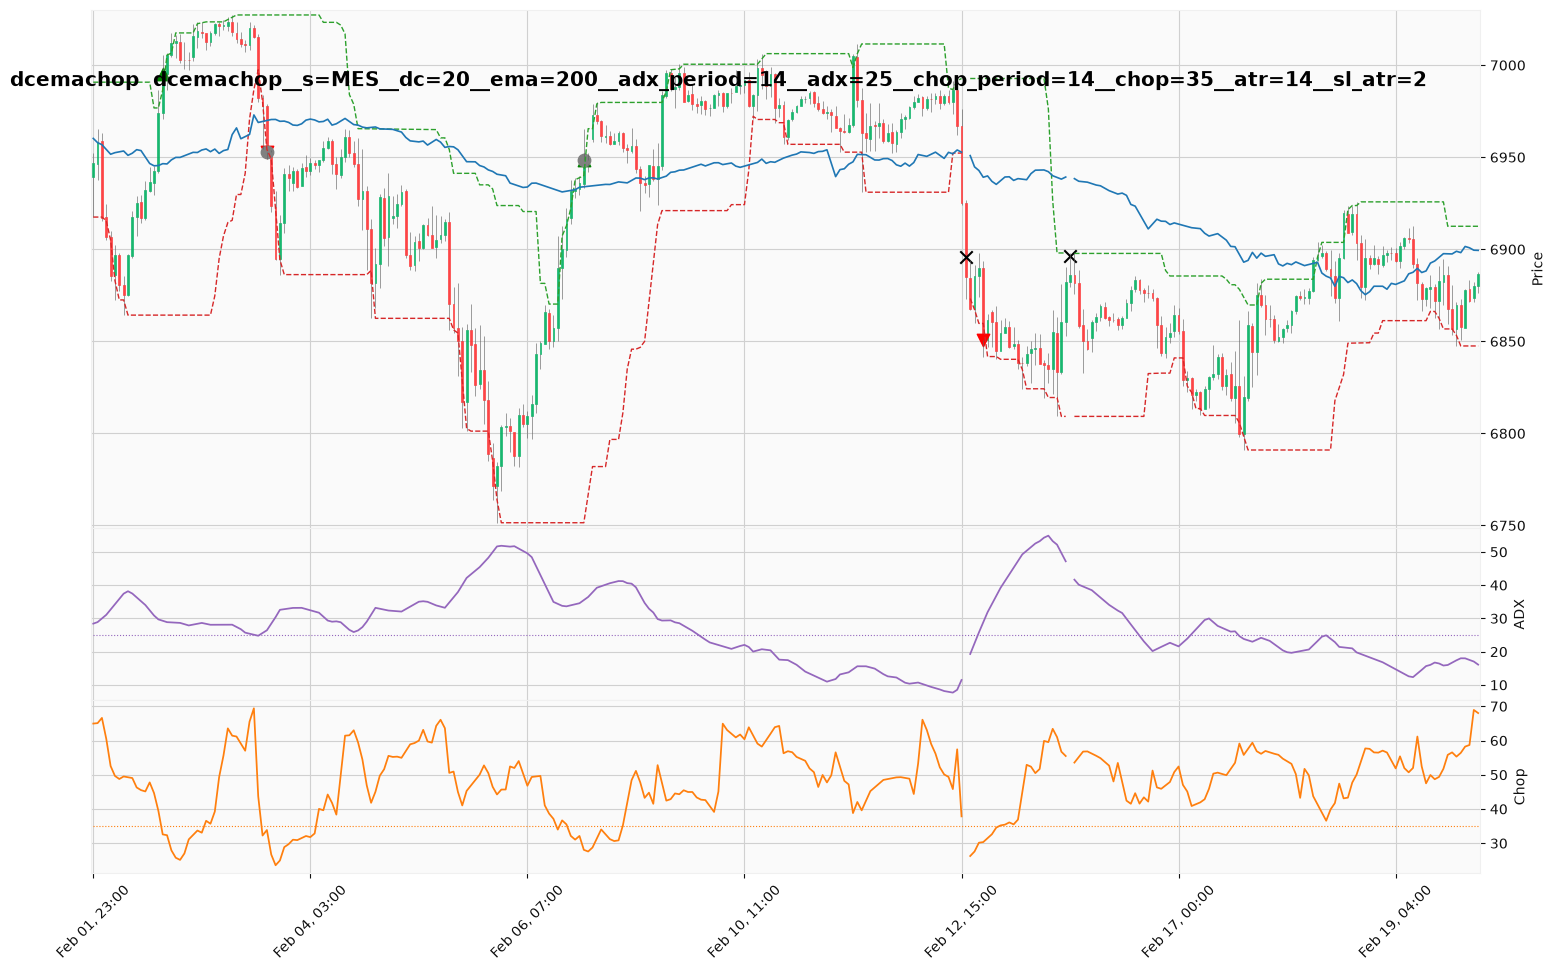

In [53]:
signals_indexed = signals.copy()
signals_indexed["timestamp"] = pd.to_datetime(signals_indexed["timestamp"])
signals_indexed = signals_indexed.sort_values("timestamp")

# Bound the OHLCV fetch to the loaded/run signal log's own range, whether
# we just ran a fresh backtest (current_timestamp is already at the last
# bar processed) or loaded a saved one (current_timestamp was never set,
# so set it explicitly here).
strategy.set_current_timestamp(signals_indexed["timestamp"].max())
ohlc_full = strategy._history_ohlc(len(signals_indexed))

plot_start = pd.Timestamp(PLOT_START_DATE) if PLOT_START_DATE else ohlc_full.index.min()
plot_end = pd.Timestamp(PLOT_END_DATE) if PLOT_END_DATE else ohlc_full.index.max()

ohlc = ohlc_full.loc[plot_start:plot_end].copy()
if ohlc.empty:
    raise ValueError(
        f"No OHLC bars for {strategy.data_symbol} between {plot_start} and {plot_end}. "
        "Check PLOT_START_DATE/PLOT_END_DATE, and that DB_PATH/TIMEFRAME/SOURCE_TIMEFRAME "
        "match whatever generated the loaded results (a saved run from a different "
        "timeframe/db combo can cover the same dates without lining up bar-for-bar)."
    )
if len(ohlc) > 600:
    print(f"Note: {len(ohlc)} bars in this window -- narrow PLOT_START_DATE/PLOT_END_DATE for a clearer chart.")

ohlc = ohlc.rename(columns={"open": "Open", "high": "High", "low": "Low", "close": "Close", "volume": "Volume"})

# Align the signal log onto these OHLC bars by nearest timestamp rather than
# requiring an exact match -- a loaded run's signal log won't necessarily
# land on the exact same timestamps as a fresh OHLCV fetch if it came from a
# different resampling path (e.g. on-the-fly 1m->1h vs the materialized 1h
# store), so exact equality is too fragile here.
bar_tolerance = timeframe_to_timedelta(strategy.bar_timeframe)

aligned = pd.merge_asof(
    pd.DataFrame({"timestamp": ohlc.index}),
    signals_indexed,
    on="timestamp",
    direction="nearest",
    tolerance=bar_tolerance,
).set_index("timestamp")

donchian_upper = aligned["donchian_upper"]
donchian_lower = aligned["donchian_lower"]
ema_line = aligned["ema"]
adx_line = aligned["adx"]
chop_line = aligned["chop"]

adx_threshold = pd.Series(strategy.parameters["adx_threshold"], index=ohlc.index)
chop_threshold = pd.Series(strategy.parameters["chop_threshold"], index=ohlc.index)

trades_in_window = tradebook.copy()
trades_in_window["timestamp"] = pd.to_datetime(trades_in_window["timestamp"])
trades_in_window = trades_in_window[
    (trades_in_window["timestamp"] >= plot_start) & (trades_in_window["timestamp"] <= plot_end)
]


def marker_series(actions, reasons=None, exclude_reasons=None):
    series = pd.Series(np.nan, index=ohlc.index)
    subset = trades_in_window[trades_in_window["action"].isin(actions)]
    if reasons is not None:
        subset = subset[subset["reason"].isin(reasons)]
    if exclude_reasons is not None:
        subset = subset[~subset["reason"].isin(exclude_reasons)]
    for _, row in subset.iterrows():
        positions = ohlc.index.get_indexer([row["timestamp"]], method="nearest", tolerance=bar_tolerance)
        if positions[0] != -1:
            series.iloc[positions[0]] = row["price"]
    return series


long_entries = marker_series(["BUY"])
short_entries = marker_series(["SELL_SHORT"])
signal_exits = marker_series(["SELL", "BUY_TO_COVER"], exclude_reasons=["ATR_STOP"])
stopped_exits = marker_series(["SELL", "BUY_TO_COVER"], reasons=["ATR_STOP"])

addplots = [
    mpf.make_addplot(donchian_upper, color="tab:green", linestyle="--", width=1.0),
    mpf.make_addplot(donchian_lower, color="tab:red", linestyle="--", width=1.0),
    mpf.make_addplot(ema_line, color="tab:blue", width=1.2),
    mpf.make_addplot(adx_line, panel=1, color="tab:purple", ylabel="ADX"),
    mpf.make_addplot(adx_threshold, panel=1, color="tab:purple", linestyle=":", width=0.8),
    mpf.make_addplot(chop_line, panel=2, color="tab:orange", ylabel="Chop"),
    mpf.make_addplot(chop_threshold, panel=2, color="tab:orange", linestyle=":", width=0.8),
]

for series, marker, color in [
    (long_entries, "^", "green"),
    (short_entries, "v", "red"),
    (signal_exits, "o", "gray"),
    (stopped_exits, "x", "black"),
]:
    if series.notna().any():
        addplots.append(
            mpf.make_addplot(series, type="scatter", markersize=80, marker=marker, color=color, panel=0)
        )

mpf.plot(
    ohlc,
    type="candle",
    style="yahoo",
    addplot=addplots,
    panel_ratios=(6, 2, 2),
    figsize=(16, 10),
    title=f"{strategy.strategy_name}  {UID}",
    ylabel="Price",
    volume=False,
    tight_layout=True,
)

In [54]:
# Print metrics
from analytics.metrics import calculate_metrics
from runners.run_futures_strats import _periods_per_year

print("\n--- Metrics ---")
if not equity.empty:
    # calculate_metrics needs the whole equity DataFrame (timestamp + equity
    # columns), not just the equity Series -- and periods_per_year has to
    # match the actual bar spacing (this notebook can run on 1d/1h/etc, and
    # the default 252 assumes daily bars, same annualization issue as
    # runners/run_futures_strats.py -- reusing its helper here).
    metrics = calculate_metrics(equity, periods_per_year=_periods_per_year(equity))
    for key, value in metrics.items():
        if isinstance(value, float):
            print(f"{key:28s} {value:,.4f}")
        else:
            print(f"{key:28s} {value}")
else:
    print("No equity history to compute metrics from.")


--- Metrics ---
initial_equity               50,000.0000
final_equity                 49,852.5970
total_return                 -0.0029
cagr                         -0.0006
annualized_volatility        0.0618
sharpe_ratio                 0.0217
sortino_ratio                0.0165
max_drawdown                 -0.0899
calmar_ratio                 -0.0063
max_drawdown_duration_days   568.0000
win_rate                     0.5064
best_day                     0.0191
worst_day                    -0.0263
positive_days                9,356.0000
negative_days                9,121.0000
flat_days                    12,066.0000
elapsed_years                5.1855


## Equity curve

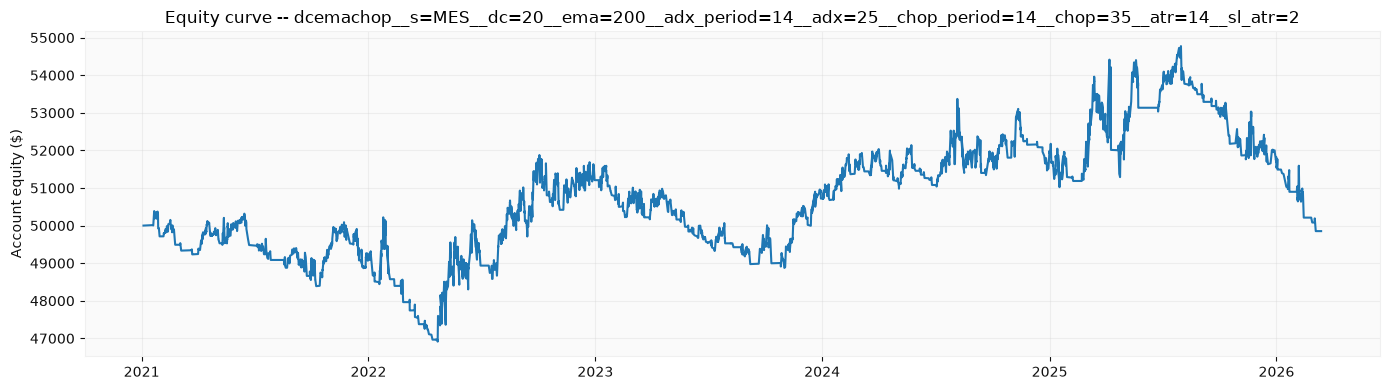

In [55]:
if not equity.empty:
    eq = equity.copy()
    eq["timestamp"] = pd.to_datetime(eq["timestamp"])

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(eq["timestamp"], eq["equity"], color="tab:blue")
    ax.set_title(f"Equity curve -- {UID}")
    ax.set_ylabel("Account equity ($)")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print("No equity history to plot.")